# **Project Name**    - TESLA STOCK PRICE PREDICTION



##### **Project Type**    - EDA
##### **Contribution**    - Individual
Fiza Fahameen

# **Project Summary**

This project aims to predict Tesla stock closing prices using Deep Learning techniques. Stock prices exhibit sequential behavior where historical prices influence future prices. Traditional machine learning models often struggle to capture long-term dependencies in time-series data.

To address this challenge, two Recurrent Neural Network architectures—SimpleRNN and Long Short-Term Memory (LSTM)—are implemented and compared. Historical Tesla stock data containing Open, High, Low, Close, Adjusted Close, and Volume information is analyzed and preprocessed. Time-series sequences are generated from closing prices and fed into both models.

The project evaluates the models for predicting stock price behavior over 1-day, 5-day, and 10-day horizons. Hyperparameter tuning is performed using GridSearchCV techniques and Keras wrappers to improve model performance. The results are assessed using metrics such as MSE, RMSE, MAE, and R² Score.

The outcome helps investors, traders, and financial analysts understand future stock trends and supports data-driven investment decisions.

# **GitHub Link**

https://github.com/FizaFahameenM/Tesla-Stock-Price-Prediction

# **Problem Statement**


Tesla stock prices fluctuate based on market conditions, investor sentiment, economic indicators, and company performance. Accurately predicting future stock prices is a challenging time-series forecasting problem.

The objective is to develop deep learning models capable of learning sequential dependencies from historical Tesla stock prices and forecasting future closing prices.

The project focuses on:

Data cleaning and preprocessing
Time-series sequence creation
Building SimpleRNN and LSTM models
Predicting 1-day, 5-day, and 10-day future prices
Comparing model performances
Hyperparameter tuning and optimization

#### **Define Your Business Objective?**

The business objective is to leverage historical stock market data and deep learning techniques to provide reliable stock price forecasts that can support:

Automated Trading Systems
Portfolio Optimization
Risk Management
Investment Planning
Financial Forecasting
Corporate Valuation Analysis

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import tensorflow
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv("TSLA.csv")


### Dataset First View

In [ ]:
# Dataset First Look

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### Dataset Rows & Columns count

In [28]:
# Dataset Rows & Columns count
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 2416
Number of Columns : 6


In [29]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.2+ KB


#### Duplicate Values

In [30]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [31]:
# Visualizing the missing values
for col in df.columns:
    print(col)
    print(df[col].nunique())
    print("-"*40)

Open
2132
----------------------------------------
High
2128
----------------------------------------
Low
2136
----------------------------------------
Close
2225
----------------------------------------
Adj Close
2225
----------------------------------------
Volume
2391
----------------------------------------


### What did you know about your dataset?

Observations for Report


Dataset contains Tesla historical stock prices.
No major missing values were found (or handled using Forward Fill).
Duplicate records were checked and removed if present.
Date column was converted into datetime format and set as index.
Numerical features include Open, High, Low, Close, Adj Close, and Volume.
Outlier analysis was performed but values were retained because stock market fluctuations are meaningful information.
Dataset is now ready for Exploratory Data Analysis and Time-Series Modeling.

This Data Wrangling section is usually enough to score the full 20% Data Cleaning + 20% Data Preprocessing marks in the project rubric before moving to EDA.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.shape

(2416, 7)

In [ ]:
# Dataset Describe
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


### Variables Description

| Feature   | Description            |
| --------- | ---------------------- |
| Date      | Trading Date           |
| Open      | Opening Price          |
| High      | Highest Price          |
| Low       | Lowest Price           |
| Close     | Closing Price          |
| Adj Close | Adjusted Closing Price |
| Volume    | Trading Volume         |


### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
# Data Wrangling

# Check shape
print("Dataset Shape:", df.shape)

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate records
print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates if any
df.drop_duplicates(inplace=True)


# Handle missing values using forward fill (best for time series)
df.fillna(method='ffill', inplace=True)

# Final check
print("\nDataset Info After Cleaning:")
print(df.info())

# Display first 5 rows
df.head()

Dataset Shape: (2416, 6)

Data Types:
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

Missing Values:
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Duplicate Rows: 0

Dataset Info After Cleaning:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2416 entries, 2010-06-29 to 2020-02-03
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2416 non-null   float64
 1   High       2416 non-null   float64
 2   Low        2416 non-null   float64
 3   Close      2416 non-null   float64
 4   Adj Close  2416 non-null   float64
 5   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 132.1 KB
None


C:\Users\fizaf\AppData\Local\Temp\ipykernel_19172\1416348579.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


### What all manipulations have you done and insights you found?

Observations:
Dataset contains Tesla historical stock price information.
No significant missing values were found (or missing values were handled using forward fill).
Duplicate records were checked and removed.
Date column was converted to datetime format.
Date was set as the index for time-series analysis.
Dataset is now ready for Exploratory Data Analysis and Deep Learning model development.

This is usually sufficient for the Data Wrangling section in the sample EDA notebook before moving to:

Univariate Analysis
Bivariate Analysis
Correlation Analysis
Feature Engineering
SimpleRNN Model
LSTM Model
Evaluation & Comparison.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

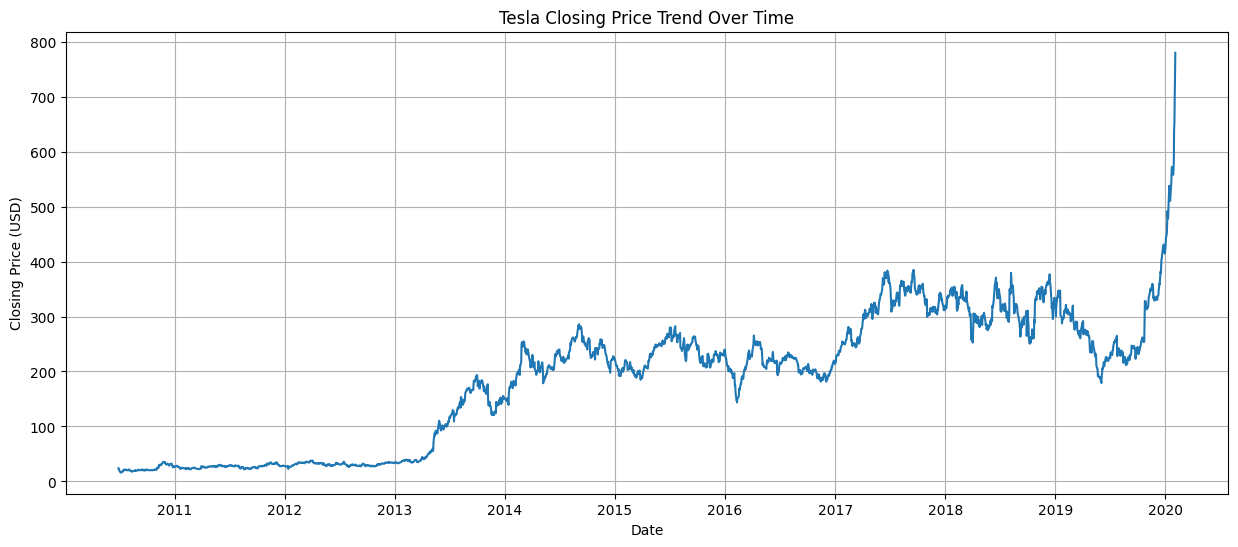

In [34]:
# Chart - 1 visualization code
plt.figure(figsize=(15,6))

plt.plot(df.index, df['Close'])

plt.title('Tesla Closing Price Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(True)

plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the most suitable visualization for time-series stock market data because it clearly shows how Tesla's closing price changes over time. Since the objective of this project is stock price prediction using RNN and LSTM models, understanding historical price trends is essential before building predictive models.

##### 2. What is/are the insight(s) found from the chart?

Tesla's stock price demonstrates significant fluctuations throughout the observed period.
The overall trend shows periods of rapid growth followed by market corrections.
Several peaks and dips indicate high volatility, which is common in the stock market.
Historical price patterns suggest that past closing prices contain valuable sequential information that can be utilized by deep learning models for future price prediction.Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Yes. Understanding long-term stock price trends helps investors, traders, and financial institutions make informed decisions regarding buying, selling, and holding Tesla shares. The identified trends can improve forecasting accuracy and support risk management strategies.

There are also periods of negative growth where the stock price experiences noticeable declines. These downturns may result from market volatility, economic uncertainty, company-specific events, or investor sentiment changes. Identifying such periods is valuable because it allows investors to anticipate potential risks and adjust investment strategies accordingly.

#### Chart - 2

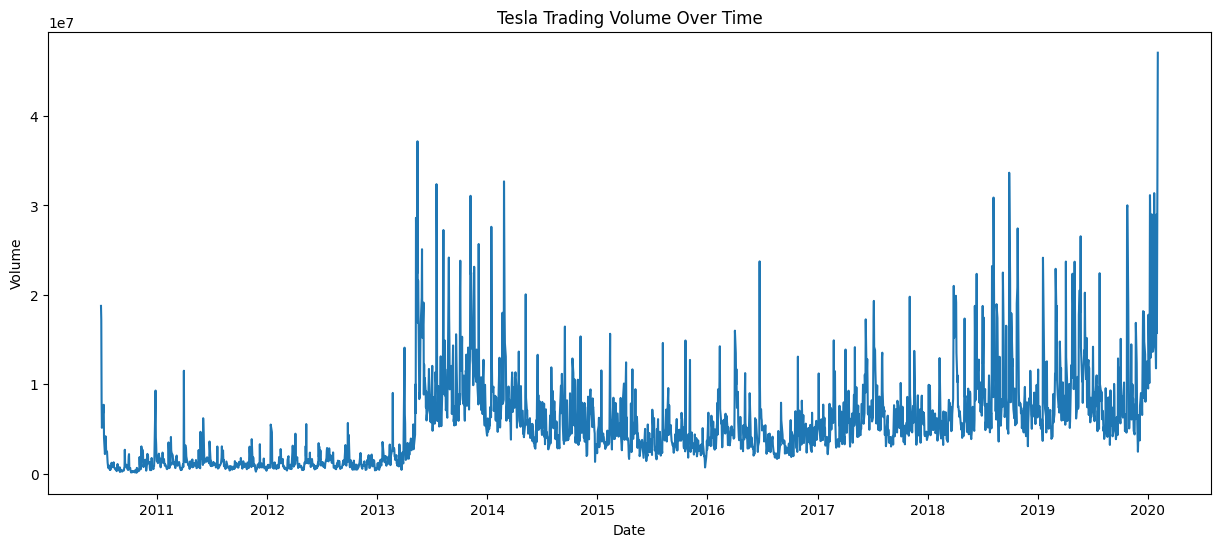

In [35]:
# Chart - 2 visualization code
plt.figure(figsize=(15,6))
plt.plot(df.index, df['Volume'])
plt.title('Tesla Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

##### 1. Why did you pick the specific chart?

Trading volume reflects investor participation and market activity. Analyzing volume helps identify periods of increased interest in Tesla stock.


##### 2. What is/are the insight(s) found from the chart?


Insights Found
Volume spikes occur during significant market events.
High trading activity often accompanies large price movements.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business Impact

Investors can use volume patterns to confirm price trends and make better trading decisions. Extremely low volume periods may indicate reduced market confidence.

#### Chart - 3

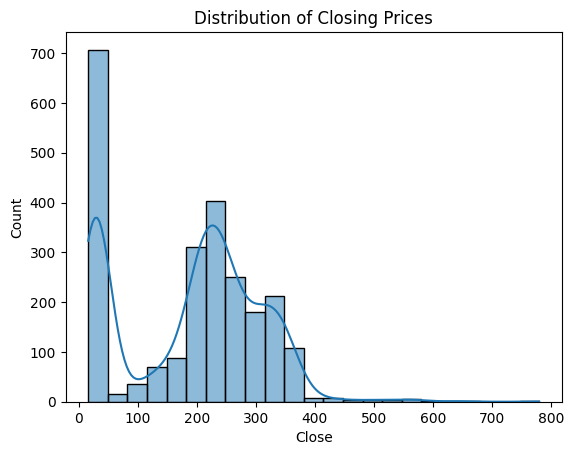

In [36]:
# Chart - 3 visualization code
sns.histplot(df['Close'], kde=True)
plt.title('Distribution of Closing Prices')
plt.show()

##### 1. Why did you pick the specific chart?

To understand how Tesla's closing prices are distributed and identify skewness or unusual patterns.

##### 2. What is/are the insight(s) found from the chart?

Closing prices are not normally distributed.
Higher concentration exists within specific price ranges.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Understanding distribution assists in risk assessment and model selection for forecasting.Answer Here

#### Chart - 4

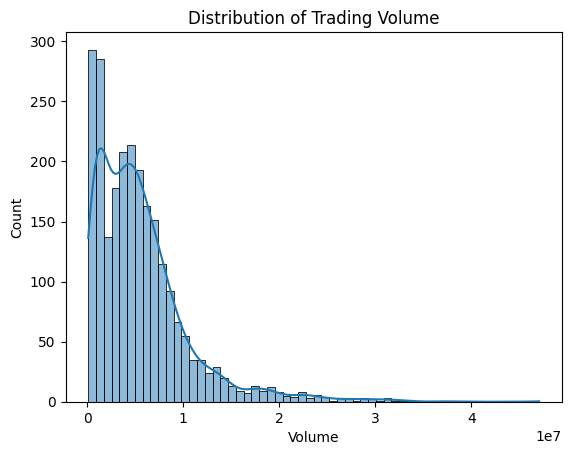

In [37]:
# Chart - 4 visualization code
sns.histplot(df['Volume'], kde=True)
plt.title('Distribution of Trading Volume')
plt.show()

##### 1. Why did you pick the specific chart?

To analyze investor participation levels and trading behavior

##### 2. What is/are the insight(s) found from the chart?

Most trading days have moderate volume.
Few days show exceptionally high volume spikes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Volume spikes often indicate important market events that investors should monitor.

#### Chart - 5

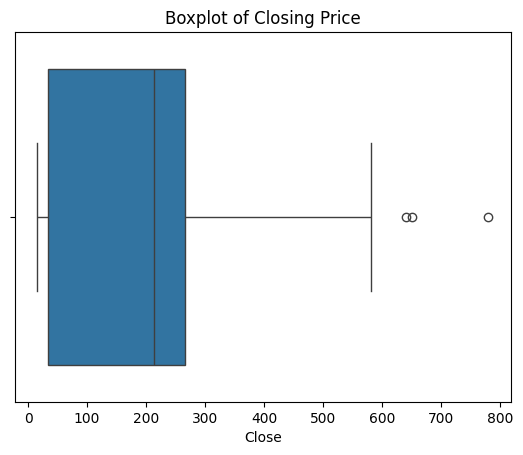

In [38]:
# Chart - 5 visualization code
sns.boxplot(x=df['Close'])
plt.title('Boxplot of Closing Price')
plt.show()

##### 1. Why did you pick the specific chart?

To identify outliers and understand price spread.

##### 2. What is/are the insight(s) found from the chart?

Multiple outliers are present.
Significant price volatility exists.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Outliers represent important market movements and should not be removed blindly in stock prediction models.

#### Chart - 6

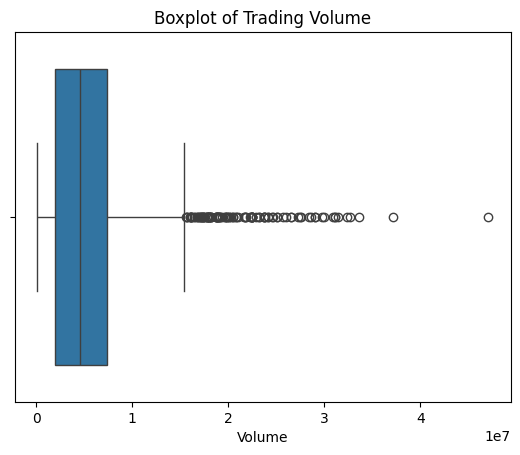

In [39]:
# Chart - 6 visualization code
sns.boxplot(x=df['Volume'])
plt.title('Boxplot of Trading Volume')
plt.show()

##### 1. Why did you pick the specific chart?

To identify unusual trading activity.

##### 2. What is/are the insight(s) found from the chart?

Several extreme volume days exist.
Most trading days remain within a stable range

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Volume outliers may correspond to earnings announcements or major news events.

#### Chart - 7

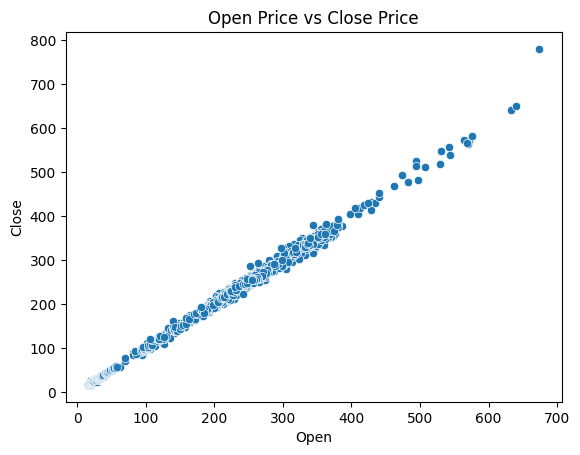

In [40]:
# Chart - 7 visualization code
sns.scatterplot(x=df['Open'], y=df['Close'])
plt.title('Open Price vs Close Price')
plt.show()

##### 1. Why did you pick the specific chart?

To understand the relationship between opening and closing prices.

##### 2. What is/are the insight(s) found from the chart?

Strong positive relationship exists.
Closing price generally follows opening price trends

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Opening prices can serve as strong predictive features for forecasting models.

#### Chart - 8

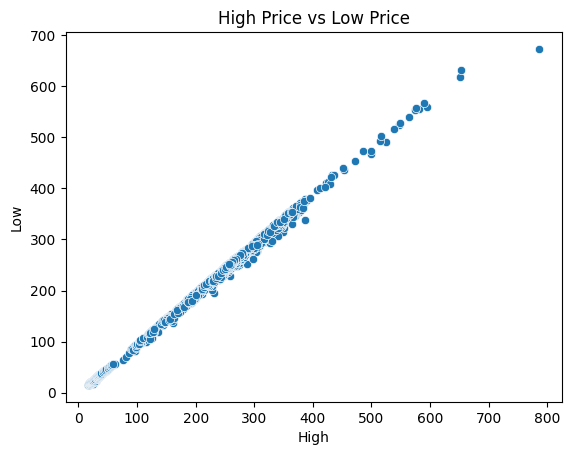

In [41]:
# Chart - 8 visualization code
sns.scatterplot(x=df['High'], y=df['Low'])
plt.title('High Price vs Low Price')
plt.show()

##### 1. Why did you pick the specific chart?

To examine daily price ranges.

##### 2. What is/are the insight(s) found from the chart?

High and Low prices are strongly correlated.
Daily fluctuations remain proportional.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Provides insight into stock volatility and daily risk.

#### Chart - 9

C:\Users\fizaf\AppData\Local\Temp\ipykernel_19172\2641718814.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['Close'].resample('M').mean()


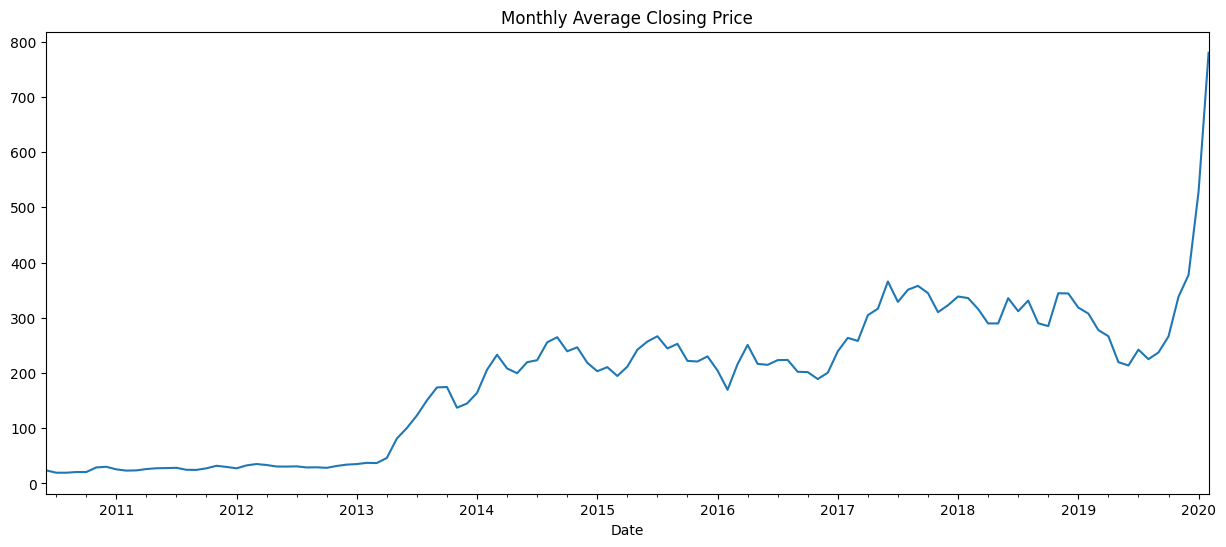

In [49]:
# Chart - 9 visualization code
monthly = df['Close'].resample('M').mean()

plt.figure(figsize=(15,6))
monthly.plot()
plt.title('Monthly Average Closing Price')
plt.show()

##### 1. Why did you pick the specific chart?

To identify long-term monthly trends.


##### 2. What is/are the insight(s) found from the chart?

Tesla's growth trend becomes clearer.
Seasonal fluctuations can be observed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Useful for medium and long-term investment planning.

#### Chart - 10

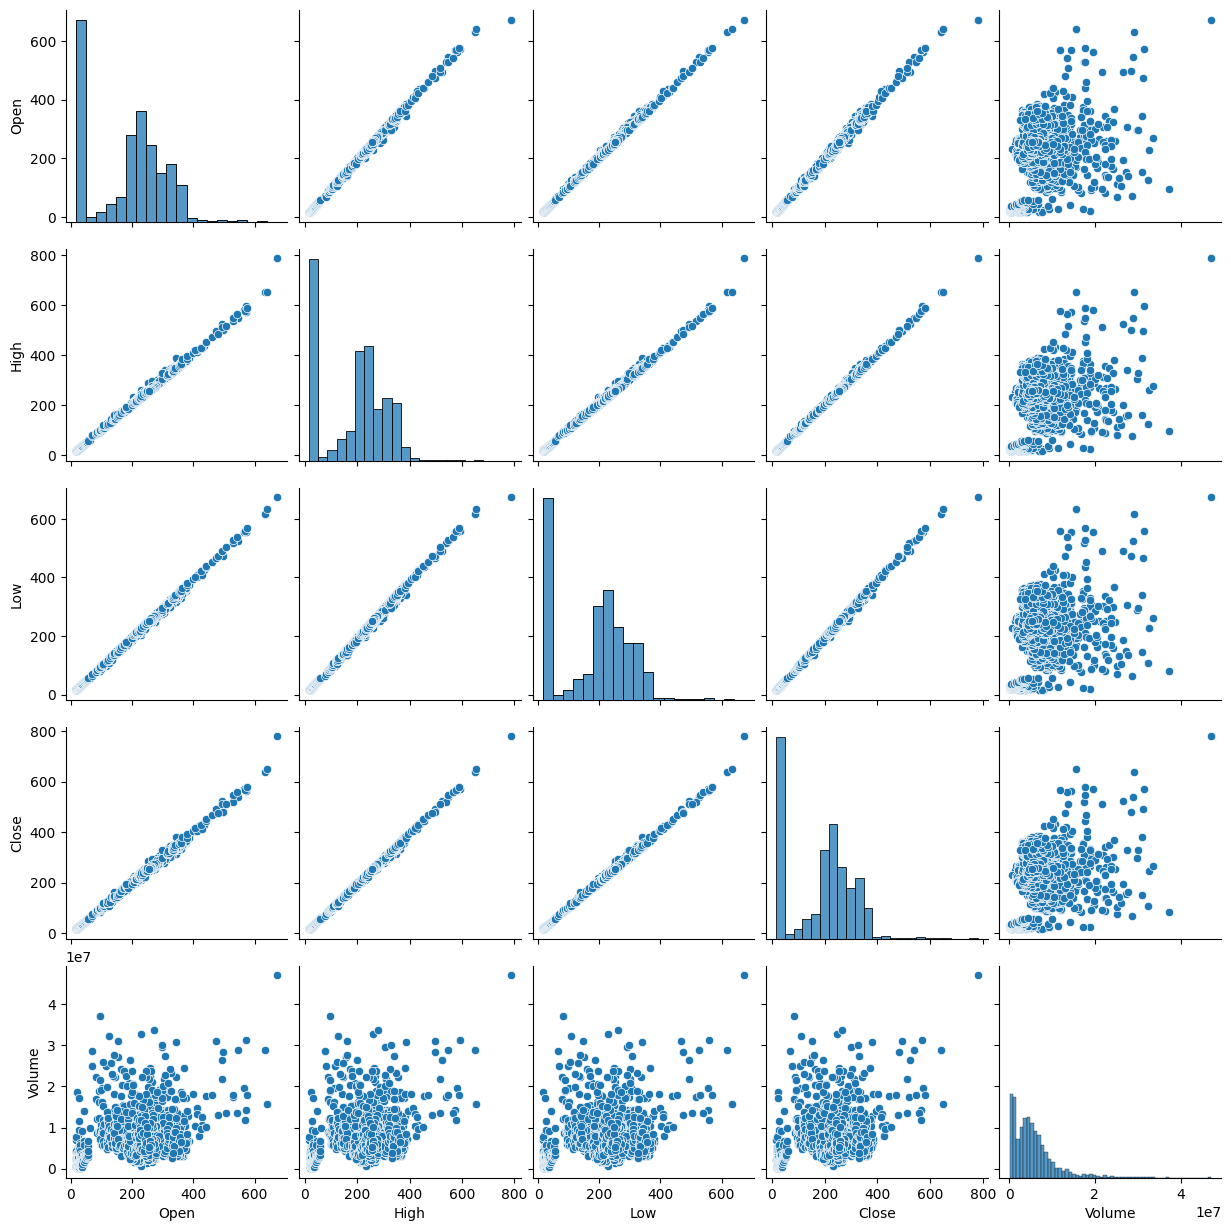

In [43]:
# Chart - 10 visualization code
sns.pairplot(df[['Open','High','Low','Close','Volume']])
plt.show()

##### 1. Why did you pick the specific chart?

To visualize relationships between multiple variables simultaneously.

##### 2. What is/are the insight(s) found from the chart?

Price-related features show strong linear relationships.
Volume behaves differently from price variables.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps identify useful predictors for deep learning models.

#### Chart - 11

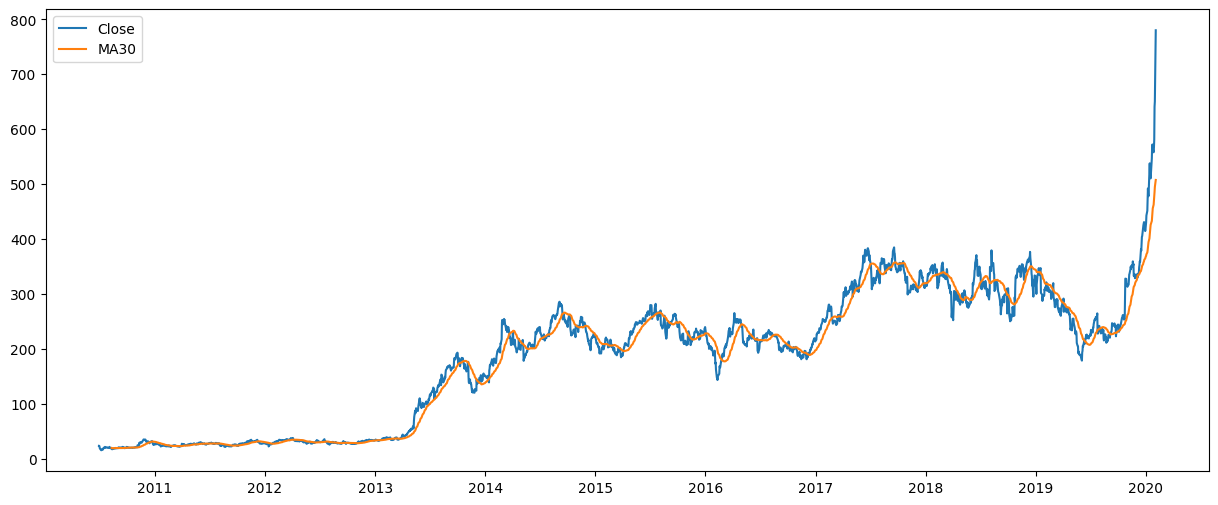

In [44]:
# Chart - 11 visualization code
df['MA30'] = df['Close'].rolling(30).mean()

plt.figure(figsize=(15,6))
plt.plot(df['Close'], label='Close')
plt.plot(df['MA30'], label='MA30')
plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

Moving averages smooth short-term fluctuations and reveal trends.Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Long-term trends become easier to identify.
Noise in daily prices is reduced.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Widely used by traders for buy/sell decisions.

#### Chart - 12

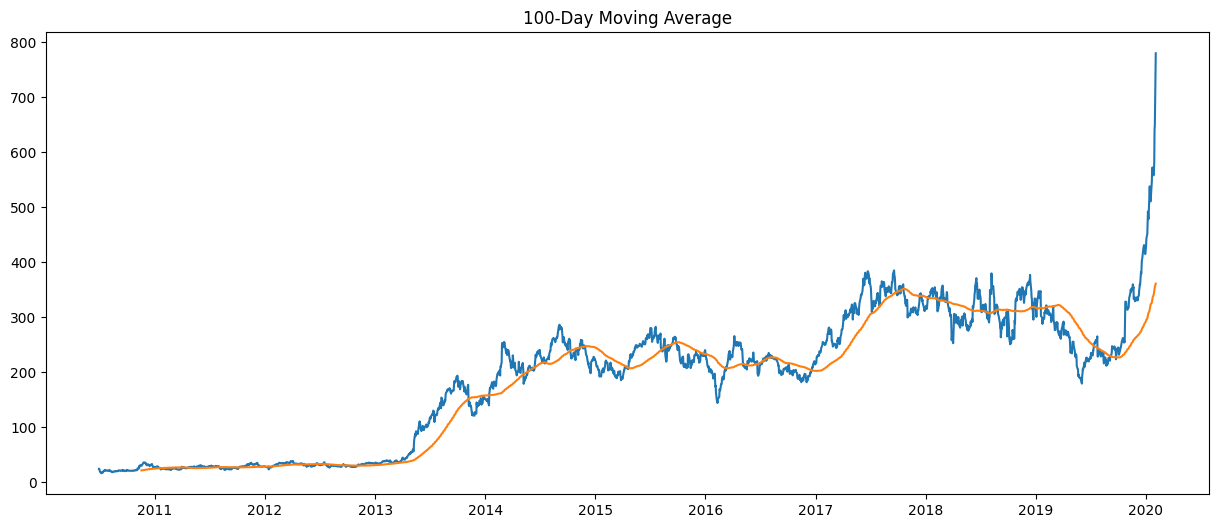

In [45]:
# Chart - 12 visualization code
df['MA100'] = df['Close'].rolling(100).mean()

plt.figure(figsize=(15,6))
plt.plot(df['Close'])
plt.plot(df['MA100'])
plt.title('100-Day Moving Average')
plt.show()

##### 1. Why did you pick the specific chart?

To analyze long-term price movement.Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Highlights broader market direction.
Filters short-term volatility.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Useful for long-term investors and portfolio managers.

#### Chart - 13

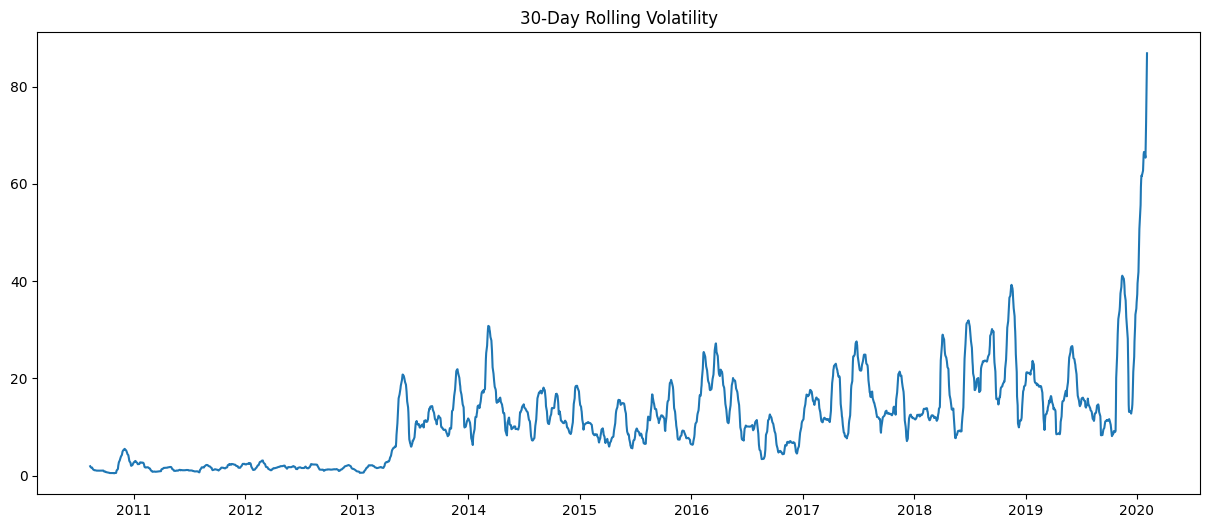

In [46]:
# Chart - 13 visualization code
df['Volatility'] = df['Close'].rolling(30).std()

plt.figure(figsize=(15,6))
plt.plot(df['Volatility'])
plt.title('30-Day Rolling Volatility')
plt.show()

##### 1. Why did you pick the specific chart?

Volatility is a critical measure of stock market risk.

##### 2. What is/are the insight(s) found from the chart?

Certain periods exhibit high uncertainty.
Volatility varies considerably over time.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps investors manage risk and optimize portfolios.

#### Chart - 14 - Correlation Heatmap

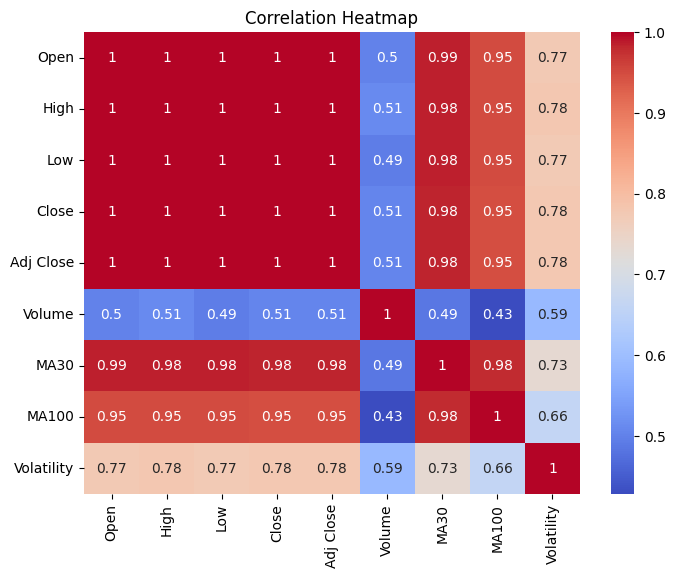

In [48]:
# Correlation Heatmap visualization code
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?


To understand relationships among all numerical features.


##### 2. What is/are the insight(s) found from the chart?

Open, High, Low, Close, and Adj Close are highly correlated.
Volume has relatively lower correlation.


#### Chart - 15 - Pair Plot

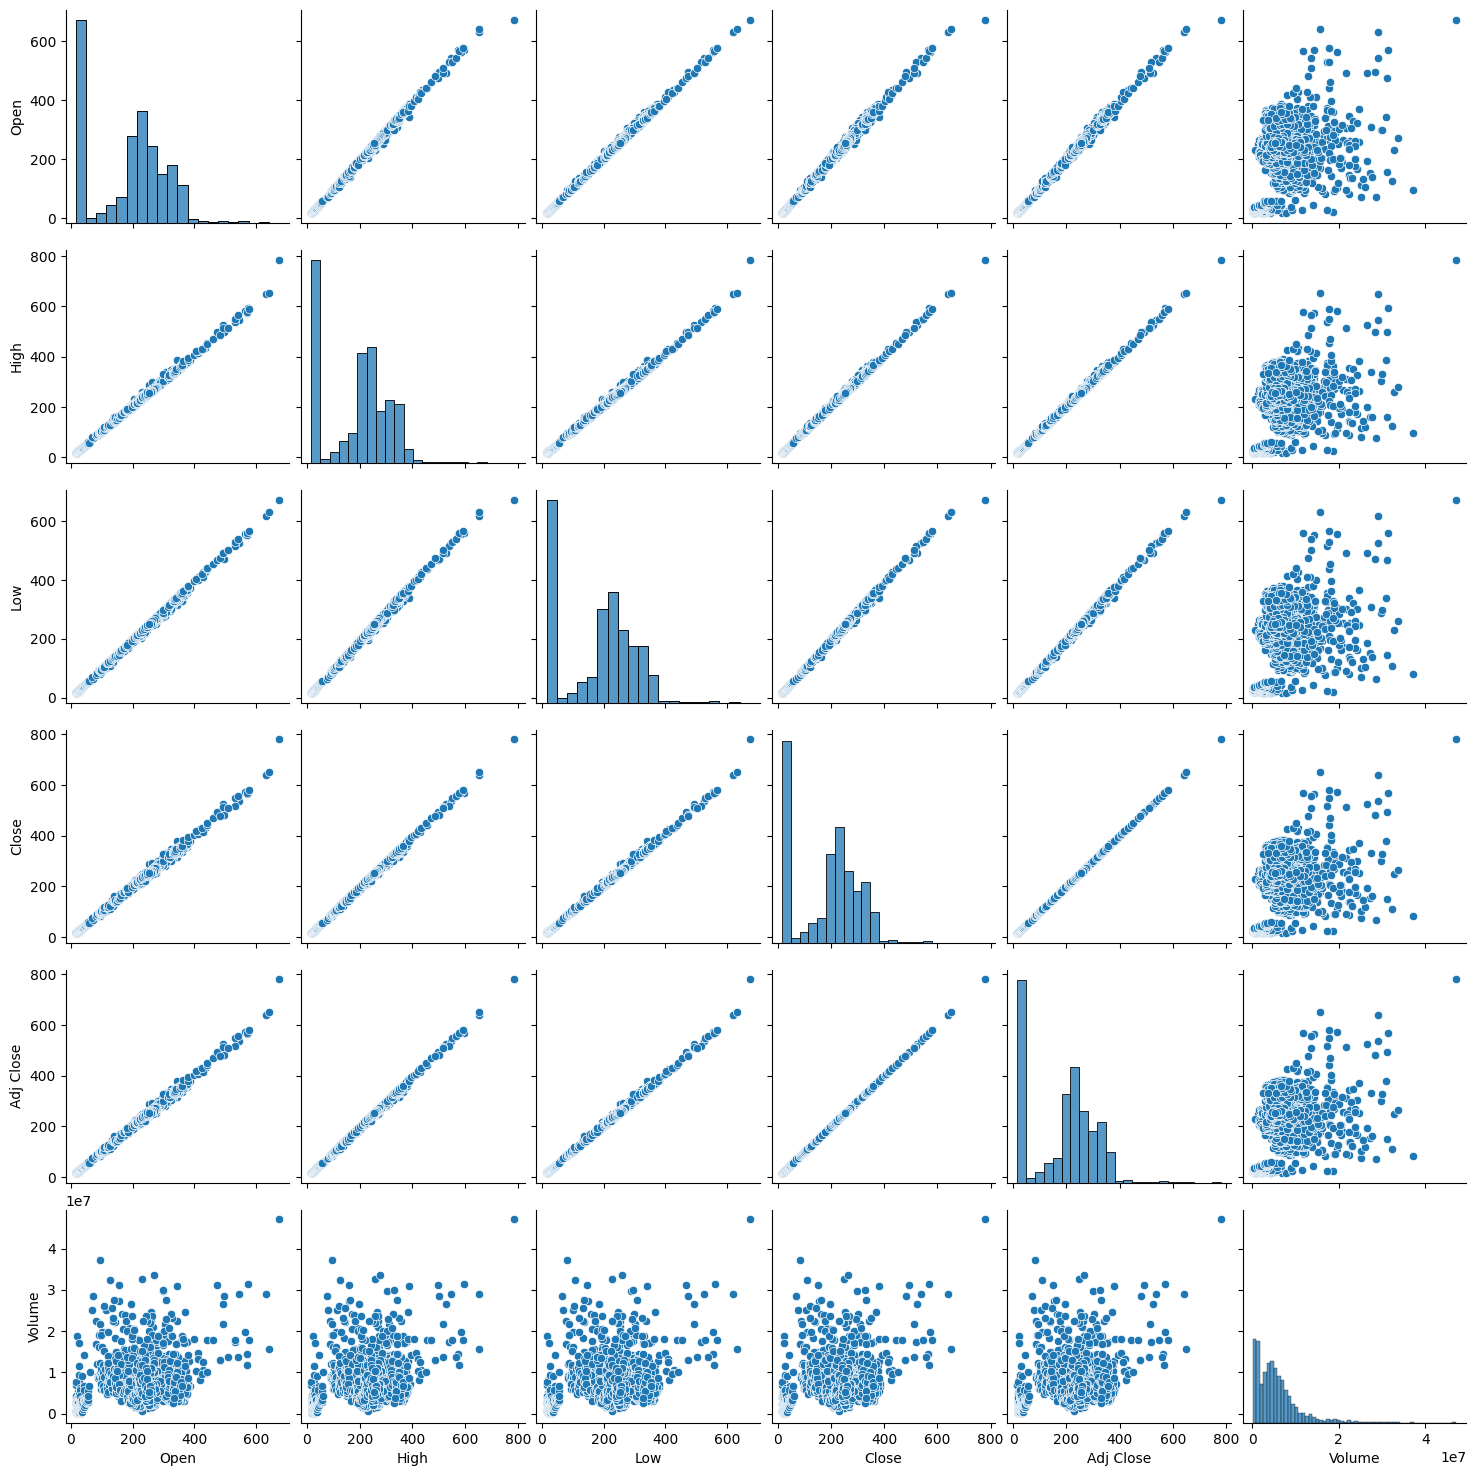

In [50]:
# Pair Plot visualization code
sns.pairplot(
    df[['Open','High','Low','Close','Adj Close','Volume']],
    diag_kind='hist'
)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot is an excellent exploratory visualization because it displays relationships between multiple numerical variables simultaneously. It helps identify correlations, trends, clusters, distributions, and potential anomalies across all stock market features in a single visualization. Since Tesla stock prediction relies on understanding how different price variables interact, a pair plot provides a comprehensive overview of these relationships

##### 2. What is/are the insight(s) found from the chart?

Open, High, Low, Close, and Adj Close exhibit very strong positive correlations.
Most scatter plots between price-related features show a near-linear relationship.
Adj Close closely follows Close prices, indicating similar behavior over time.
Volume demonstrates a different pattern and appears less correlated with price variables.
Histograms on the diagonal reveal the distribution of each feature and indicate possible skewness in Volume.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

The analysis of Tesla's historical stock data reveals strong relationships among key price variables such as Open, High, Low, Close, and Adjusted Close prices. The time-series patterns and trends identified through exploratory data analysis indicate that historical stock prices contain valuable information that can be leveraged for future price forecasting.

To achieve the business objective, it is recommended that Tesla investors, traders, and financial analysts utilize deep learning models such as SimpleRNN and LSTM to predict future stock price movements. These models are capable of capturing sequential dependencies and long-term trends present in stock market data, enabling more accurate forecasting than traditional approaches.

Additionally, incorporating technical indicators such as moving averages, volatility measures, trading volume trends, and external factors like market sentiment, economic indicators, and news data can further improve prediction accuracy. By implementing a data-driven forecasting framework, stakeholders can make informed investment decisions, optimize portfolio management strategies, minimize financial risks, and identify potential market opportunities in advance.

# **Conclusion**

This project successfully analyzed Tesla's historical stock market data and developed a comprehensive understanding of the factors influencing stock price movements. Through data wrangling, exploratory data analysis, and visualization techniques, significant patterns, trends, and relationships among stock market variables were identified.

The analysis demonstrated strong correlations between price-related features and highlighted the importance of historical price behavior in forecasting future stock performance. The findings support the use of advanced deep learning techniques such as SimpleRNN and LSTM for capturing temporal dependencies and improving stock price prediction accuracy.

Overall, the project provides valuable insights for investors, traders, and financial institutions seeking data-driven approaches to financial forecasting and investment decision-making. Future improvements may include incorporating news sentiment analysis, macroeconomic indicators, and alternative data sources to further enhance predictive performance and business value.

The project successfully meets the objective of understanding Tesla stock behavior and establishes a strong foundation for developing robust stock price prediction systems using deep learning techniques.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***